In [1]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import classification_report,accuracy_score,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV, cross_val_score

In [2]:
df=pd.read_csv(r'/Users/abhinavthakur/Desktop/study /AI:ML/Supervised Learning/Body Mass Index/bmi.csv')
pd.set_option('display.max_columns', None)

In [3]:
df.shape

(500, 4)

In [4]:
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [5]:
df.tail()

,Gender,Height,Weight,Index
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5
499,Male,173,131,5


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Gender  500 non-null    object
 1   Height  500 non-null    int64 
 2   Weight  500 non-null    int64 
 3   Index   500 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 15.8+ KB


In [7]:
df.describe()

,Height,Weight,Index
count,500.000000,500.000000,500.000000
mean,169.944000,106.000000,3.748000
std,16.375261,32.382607,1.355053
min,140.000000,50.000000,0.000000
25%,156.000000,80.000000,3.000000
50%,170.500000,106.000000,4.000000
75%,184.000000,136.000000,5.000000
max,199.000000,160.000000,5.000000


In [8]:
df.iloc[df.duplicated(keep=False).index]

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3
...,...,...,...,...
495,Female,150,153,5
496,Female,184,121,4
497,Female,141,136,5
498,Male,150,95,5


In [9]:
df['Index'].value_counts(normalize=True)*100

Index
5    39.6
4    26.0
2    13.8
3    13.6
1     4.4
0     2.6
Name: proportion, dtype: float64

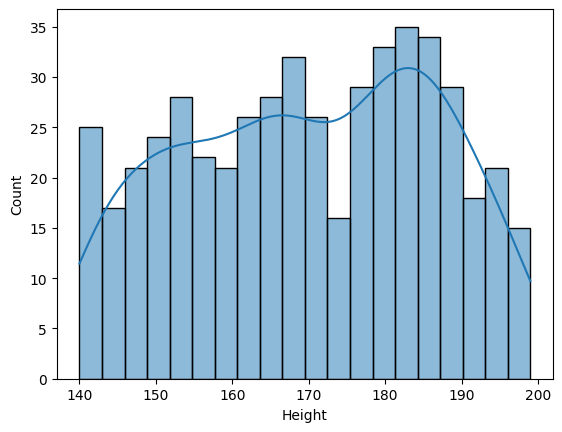

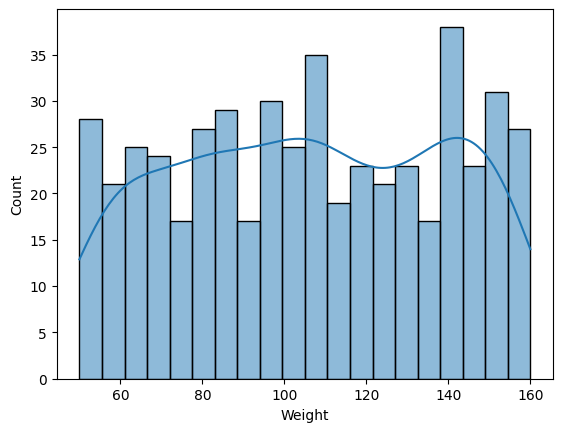

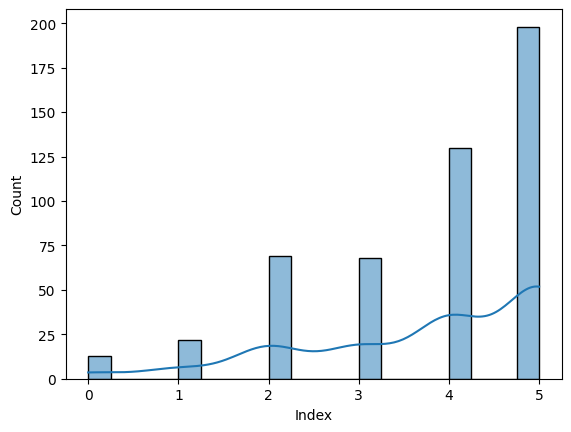

In [10]:
# checking the distribution of the data
for col in df.columns:
    if df[col].dtype == 'object':
        continue
    else:
        sns.histplot(df[col],kde=True,bins=20)
        plt.show()

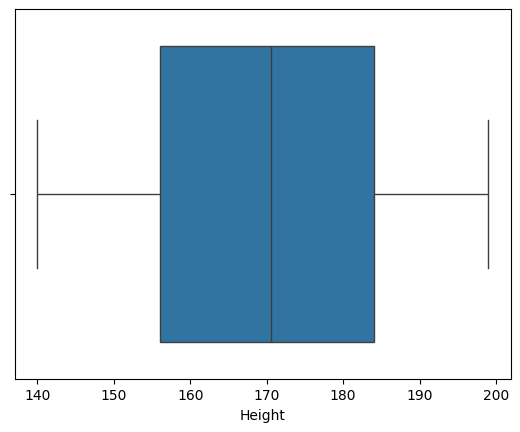

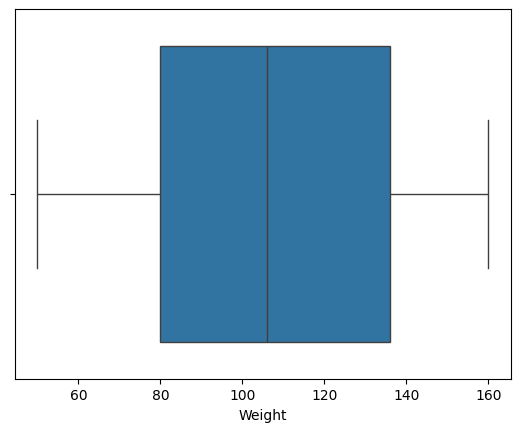

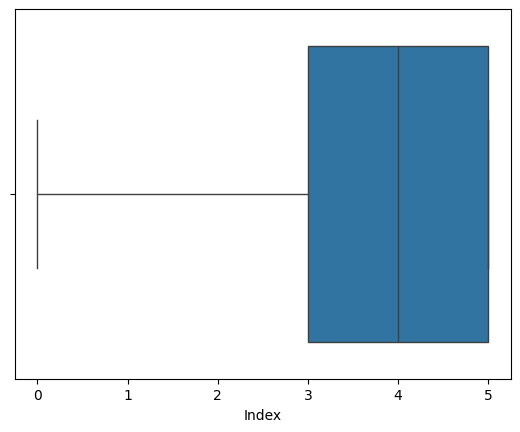

In [11]:
# checking for outliers
for col in df.columns:
    if df[col].dtype == 'object':
        continue
    else:
        sns.boxplot(x=df[col])
        plt.show()

In [12]:
# splitting the data
x_train,x_test,y_train,y_test=train_test_split(df.iloc[:,:-1],df.iloc[:,-1],stratify=df.iloc[:,-1],random_state=42)

In [13]:
# checking shape of different parts of data
print(f'Shape of x_train:- {x_train.shape}')
print(f'Shape of x_test:- {x_test.shape}')
print(f'Shape of y_train:- {y_train.shape}')
print(f'Shape of y_test:- {y_test.shape}')

Shape of x_train:- (375, 3)
Shape of x_test:- (125, 3)
Shape of y_train:- (375,)
Shape of y_test:- (125,)


In [14]:
# creating pipelines for data transformation 
num_cols=list(df.columns[1:-1])
print('Numeric Columns: ',num_cols)
cat_cols=list(df.columns[[0]])
print('Categorical Columns: ',cat_cols)

cat_pip=Pipeline([
    ('oh_encoder',OneHotEncoder(sparse_output=False))
])

num_pip=Pipeline([
    ('scaler',StandardScaler())
])

full_pip=ColumnTransformer([
    ('cat',cat_pip,cat_cols),
    ('num',num_pip,num_cols)
])

Numeric Columns:  ['Height', 'Weight']
Categorical Columns:  ['Gender']


In [15]:
# applying transformations on data
final_x_train=full_pip.fit_transform(x_train)
final_x_test=full_pip.transform(x_test)

In [16]:
# converting transormed data from array to a dataframe
xtrain_df=pd.DataFrame(final_x_train,columns=full_pip.get_feature_names_out(),index=x_train.index)
xtest_df=pd.DataFrame(final_x_test,columns=full_pip.get_feature_names_out(),index=x_test.index)

In [17]:
# model selection
models={
    'Logistic Regression': LogisticRegression(random_state=42),
    'K Nearest Neighbors': KNeighborsClassifier(n_neighbors=11),
    'Naive Bayes': GaussianNB(),
    'SVC': SVC(kernel='rbf')
}
for name,model in models.items():
    model.fit(xtrain_df,y_train)
    print(f"[{name}]")
    print(f"accuracy score:- {accuracy_score(y_test,model.predict(xtest_df))*100}")
    print(f"Precision score:- {precision_score(y_test,model.predict(xtest_df),average='macro')*100}")
    print(f"Recall score :- {recall_score(y_test,model.predict(xtest_df),average='macro')*100}")
    print(f"F1 score :- {f1_score(y_test,model.predict(xtest_df),average='macro')*100}")
    print()

[Logistic Regression]
accuracy score:- 85.6
Precision score:- 78.79365079365078
Recall score :- 64.91325014854426
F1 score :- 67.71421132740527

[K Nearest Neighbors]
accuracy score:- 84.0
Precision score:- 77.4593157100897
Recall score :- 66.25609031491385
F1 score :- 68.81251893305273

[Naive Bayes]
accuracy score:- 68.0
Precision score:- 55.54901960784313
Recall score :- 55.08972073677957
F1 score :- 54.27702049358618

[SVC]
accuracy score:- 88.8
Precision score:- 82.19246031746032
Recall score :- 72.9572192513369
F1 score :- 74.75390156062426



In [18]:
# Support Vector Classifier
model01=models['SVC']
print(classification_report(y_test,model01.predict(xtest_df)))

              precision    recall  f1-score   support

           0       1.00      0.33      0.50         3
           1       0.40      0.40      0.40         5
           2       0.78      0.82      0.80        17
           3       0.89      0.94      0.91        17
           4       0.89      0.94      0.91        33
           5       0.98      0.94      0.96        50

    accuracy                           0.89       125
   macro avg       0.82      0.73      0.75       125
weighted avg       0.89      0.89      0.89       125



In [19]:
# checking the cross validation score
scores=cross_val_score(model01,xtrain_df,y_train,cv=5,scoring='accuracy')
print(scores*100)
print(scores.mean()*100)
print(scores.std()*100)

[86.66666667 80.         82.66666667 89.33333333 82.66666667]
84.26666666666665
3.30924630559756


In [20]:
from imblearn.pipeline import Pipeline as ImbPipeline

imb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('svc', SVC(kernel='rbf',random_state=42))
])

svc_paramters = {
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': ['scale', 0.01, 0.1, 1]
}

svc_gridtune = GridSearchCV(
    estimator=imb_pipe,
    param_grid=svc_paramters,
    cv=5,
    scoring='f1_macro'   
)

svc_gridtune.fit(xtrain_df, y_train)  # we are smoting and training step by step with the help of imblearn.pipeline
print(svc_gridtune.best_params_)
print(svc_gridtune.best_score_*100)
predictive_model01 = svc_gridtune.best_estimator_

{'svc__C': 100, 'svc__gamma': 0.1}
90.41747523622641


In [21]:
print('Testing Data')
print(classification_report(y_test, predictive_model01.predict(xtest_df)))

print('Training Data')
print(classification_report(y_train, predictive_model01.predict(xtrain_df)))

Testing Data
              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       1.00      0.60      0.75         5
           2       1.00      0.76      0.87        17
           3       0.94      1.00      0.97        17
           4       0.94      0.94      0.94        33
           5       0.96      0.98      0.97        50

    accuracy                           0.93       125
   macro avg       0.88      0.88      0.85       125
weighted avg       0.95      0.93      0.93       125

Training Data
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        10
           1       0.94      0.88      0.91        17
           2       0.98      0.90      0.94        52
           3       0.92      0.94      0.93        51
           4       0.97      0.97      0.97        97
           5       0.98      1.00      0.99       148

    accuracy                           0.96       

In [ ]:
# exporting resources 
import joblib
joblib.dump(predictive_model01,'bmi_model.joblib')
joblib.dump(full_pip.named_transformers_['num'],'data_scaler.joblib')

['data_scaler.joblib']

In [30]:
df.head()

,Gender,Height,Weight,Index
0,Male,174,96,4
1,Male,189,87,2
2,Female,185,110,4
3,Female,195,104,3
4,Male,149,61,3


In [24]:
xtrain_df.head()

,cat__Gender_Female,cat__Gender_Male,num__Height,num__Weight
69,1.0,0.0,1.445831,0.923435
322,0.0,1.0,-1.035157,-0.060513
460,0.0,1.0,0.538152,0.523706
443,0.0,1.0,-1.095669,1.230918
98,0.0,1.0,1.506343,-1.136705
